/tmp/ipykernel_16919/1267369812.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


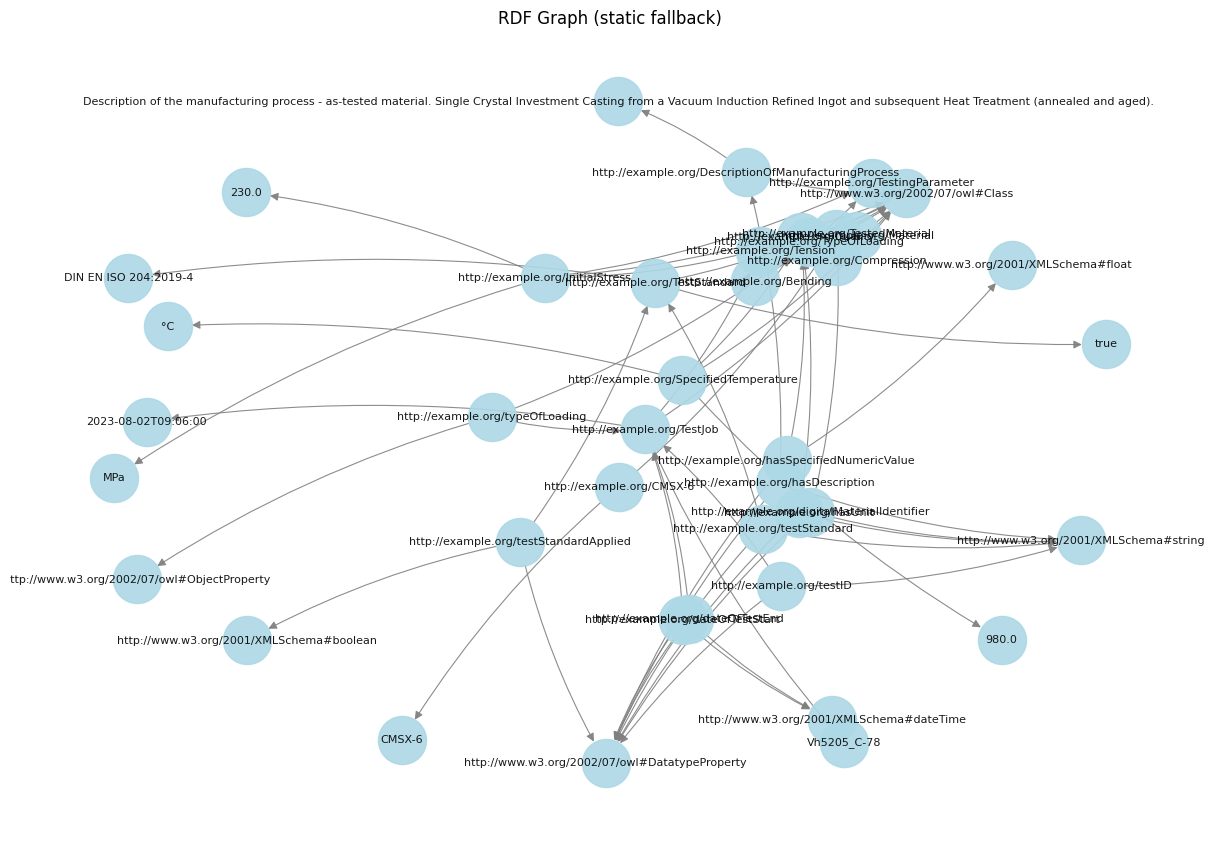

In [6]:
import networkx as nx
import matplotlib.pyplot as plt
from rdflib import Graph
from pyvis.network import Network
from IPython.display import HTML, display

# Load RDF sample file
shacl_graph = Graph()
shacl_graph.parse("shacl_validation/rdfGraph_smallExample.ttl", format="turtle")

# Create a directed graph
G = nx.DiGraph()

# Add edges based on RDF triples
for subj, pred, obj in shacl_graph:
    G.add_edge(str(subj), str(obj), label=str(pred))

# Identify root nodes (nodes with no incoming edges)
root_nodes = {node for node in G.nodes if G.in_degree(node) == 0}

# Create Pyvis Network (inline resources may still be blocked by some VS Code renderers)
net = Network(notebook=True, directed=True, height="600px", width="100%", cdn_resources="in_line")

# Add nodes and edges to Pyvis with hierarchical settings
for node in G.nodes:
    hidden = node not in root_nodes  # Hide non-root nodes initially
    net.add_node(node, label=node, title=node, hidden=hidden, physics=False)

for u, v, d in G.edges(data=True):
    net.add_edge(u, v, title=d["label"], hidden=True)  # Initially hidden edges

# Configure hierarchical layout
net.toggle_physics(False)
net.set_options("""
var options = {
  "layout": {
    "hierarchical": {
      "enabled": true,
      "direction": "UD",
      "sortMethod": "directed"
    }
  },
  "interaction": {
    "hover": true,
    "navigationButtons": true
  },
  "physics": {
    "enabled": false
  }
}
""")

# Save interactive HTML
html_file = "shacl_graph.html"
net.write_html(html_file)

# Try to display interactive HTML
display(HTML(filename=html_file))

# Always show a static fallback in notebook output
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="lightblue",
    edge_color="gray",
    node_size=1200,
    font_size=8,
    arrows=True,
    alpha=0.9,
    arrowsize=12,
    width=0.8,
    connectionstyle="arc3,rad=0.08",
)
plt.title("RDF Graph (static fallback)")
plt.tight_layout()
plt.show()
